# Logistic Regression with Grid Search for Loan Risk Prediction

This notebook implements a logistic regression model with comprehensive hyperparameter tuning using GridSearchCV. The model predicts loan risk based on the HELOC dataset.

## Key Features:
- Grid search hyperparameter tuning
- Stratified cross-validation to ensure balanced class distribution
- Cross-validation variance analysis to ensure model stability
- Comprehensive evaluation metrics on test dataset

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, 
    roc_curve, auc, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load and Explore Data

In [2]:
# Load the dataset
df = pd.read_csv("data/heloc_dataset_v1.csv", sep=",")

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (10459, 24)

First few rows:


,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,...,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,...,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,...,25,0,1,1,51,89,3,1,0,80


In [3]:
# Check target variable distribution
print("Target variable distribution:")
print(df['RiskPerformance'].value_counts())
print("\nPercentage:")
print(df['RiskPerformance'].value_counts(normalize=True) * 100)

Target variable distribution:
RiskPerformance
Bad     5459
Good    5000
Name: count, dtype: int64

Percentage:
RiskPerformance
Bad     52.194282
Good    47.805718
Name: proportion, dtype: float64


In [4]:
# Check for missing values and special codes
print("Missing values per column:")
print(df.isnull().sum())

# Check for special codes (-9, -8, -7)
special_codes = [-9, -8, -7]
print("\nSpecial codes count:")
for col in df.columns[1:]:
    special_count = df[col].isin(special_codes).sum()
    if special_count > 0:
        print(f"{col}: {special_count}")

Missing values per column:
RiskPerformance                       0
ExternalRiskEstimate                  0
MSinceOldestTradeOpen                 0
MSinceMostRecentTradeOpen             0
AverageMInFile                        0
NumSatisfactoryTrades                 0
NumTrades60Ever2DerogPubRec           0
NumTrades90Ever2DerogPubRec           0
PercentTradesNeverDelq                0
MSinceMostRecentDelq                  0
MaxDelq2PublicRecLast12M              0
MaxDelqEver                           0
NumTotalTrades                        0
NumTradesOpeninLast12M                0
PercentInstallTrades                  0
MSinceMostRecentInqexcl7days          0
NumInqLast6M                          0
NumInqLast6Mexcl7days                 0
NetFractionRevolvingBurden            0
NetFractionInstallBurden              0
NumRevolvingTradesWBalance            0
NumInstallTradesWBalance              0
NumBank2NatlTradesWHighUtilization    0
PercentTradesWBalance                 0
dtype: int64


## 3. Data Preprocessing

In [5]:
# Extract features and target
variable_names = list(df.columns[1:])
X = df[variable_names].values

# Transform target variable from categorical to binary
y = df.RiskPerformance.values
mask = y == "Bad"
y[mask] = 1
y[~mask] = 0
y = y.astype(int)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass distribution in target:")
print(f"Class 0 (Good): {(y == 0).sum()} ({(y == 0).sum() / len(y) * 100:.2f}%)")
print(f"Class 1 (Bad): {(y == 1).sum()} ({(y == 1).sum() / len(y) * 100:.2f}%)")

Features shape: (10459, 23)
Target shape: (10459,)

Class distribution in target:
Class 0 (Good): 5000 (47.81%)
Class 1 (Bad): 5459 (52.19%)


In [6]:
# Handle special codes by replacing with median
X_processed = X.copy().astype(float)
special_codes = [-9, -8, -7]

for i in range(X_processed.shape[1]):
    # Replace special codes with NaN
    mask = np.isin(X_processed[:, i], special_codes)
    X_processed[mask, i] = np.nan
    
    # Impute with median
    median_val = np.nanmedian(X_processed[:, i])
    X_processed[np.isnan(X_processed[:, i]), i] = median_val

print("Special codes handled and imputed with median values")

Special codes handled and imputed with median values


## 4. Train-Test Split

In [7]:
# Split data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining set class distribution:")
print(f"Class 0: {(y_train == 0).sum()} ({(y_train == 0).sum() / len(y_train) * 100:.2f}%)")
print(f"Class 1: {(y_train == 1).sum()} ({(y_train == 1).sum() / len(y_train) * 100:.2f}%)")
print("\nTest set class distribution:")
print(f"Class 0: {(y_test == 0).sum()} ({(y_test == 0).sum() / len(y_test) * 100:.2f}%)")
print(f"Class 1: {(y_test == 1).sum()} ({(y_test == 1).sum() / len(y_test) * 100:.2f}%)")

Training set size: (8367, 23)
Test set size: (2092, 23)

Training set class distribution:
Class 0: 4000 (47.81%)
Class 1: 4367 (52.19%)

Test set class distribution:
Class 0: 1000 (47.80%)
Class 1: 1092 (52.20%)


In [8]:
# Standardize features (important for logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized (mean=0, std=1)")
print(f"Training set mean: {X_train_scaled.mean():.6f}")
print(f"Training set std: {X_train_scaled.std():.6f}")

Features standardized (mean=0, std=1)
Training set mean: 0.000000
Training set std: 1.000000


## 5. Grid Search with Cross-Validation

In [9]:
# Define parameter grid for logistic regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Regularization type
    'solver': ['liblinear', 'saga'],  # Solvers that support both L1 and L2
    'max_iter': [1000, 2000, 5000],  # Maximum iterations
    'class_weight': [None, 'balanced']  # Handle class imbalance
}

print("Parameter grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")
print(f"\nTotal combinations: {np.prod([len(v) for v in param_grid.values()])}")

Parameter grid:
  C: [0.001, 0.01, 0.1, 1, 10, 100]
  penalty: ['l1', 'l2']
  solver: ['liblinear', 'saga']
  max_iter: [1000, 2000, 5000]
  class_weight: [None, 'balanced']

Total combinations: 144


In [10]:
# Set up stratified k-fold cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize logistic regression
log_reg = LogisticRegression(random_state=42)

# Perform grid search
print("Starting Grid Search with Stratified 5-Fold Cross-Validation...")
print("This may take a few minutes...\n")

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=2,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

print("\nGrid Search completed!")

Starting Grid Search with Stratified 5-Fold Cross-Validation...
This may take a few minutes...

Fitting 5 folds for each of 144 candidates, totalling 720 fits



Grid Search completed!


## 6. Grid Search Results and Best Parameters

In [11]:
# Display best parameters and score
print("="*60)
print("BEST PARAMETERS FROM GRID SEARCH")
print("="*60)
for param, value in grid_search.best_params_.items():
    print(f"{param}: {value}")

print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
print("="*60)

BEST PARAMETERS FROM GRID SEARCH
C: 0.001
class_weight: None
max_iter: 1000
penalty: l2
solver: saga

Best Cross-Validation Accuracy: 0.7232


In [12]:
# Create a DataFrame with grid search results
results_df = pd.DataFrame(grid_search.cv_results_)

# Display top 10 parameter combinations
print("\nTop 10 Parameter Combinations:")
top_results = results_df.nsmallest(10, 'rank_test_score')[[
    'rank_test_score', 'mean_test_score', 'std_test_score',
    'param_C', 'param_penalty', 'param_solver', 'param_max_iter', 'param_class_weight'
]]
print(top_results.to_string(index=False))


Top 10 Parameter Combinations:
 rank_test_score  mean_test_score  std_test_score  param_C param_penalty param_solver  param_max_iter param_class_weight
               1         0.723199        0.011290    0.001            l2         saga            1000               None
               1         0.723199        0.011290    0.001            l2         saga            2000               None
               1         0.723199        0.011290    0.001            l2         saga            5000               None
               4         0.722841        0.010919    0.100            l1         saga            1000               None
               4         0.722841        0.010919    0.100            l1         saga            2000               None
               4         0.722841        0.010919    0.100            l1         saga            5000               None
               7         0.722482        0.010597    0.100            l1    liblinear            1000               None


## 7. Cross-Validation Variance Analysis

In [13]:
# Analyze variance across CV folds for best model
best_idx = grid_search.best_index_

# Extract scores for each fold
fold_scores = []
for i in range(5):
    fold_scores.append(results_df.loc[best_idx, f'split{i}_test_score'])

print("="*60)
print("CROSS-VALIDATION VARIANCE ANALYSIS (Best Model)")
print("="*60)
print(f"Mean CV Accuracy: {np.mean(fold_scores):.4f}")
print(f"Std Dev CV Accuracy: {np.std(fold_scores):.4f}")
print(f"Min CV Accuracy: {np.min(fold_scores):.4f}")
print(f"Max CV Accuracy: {np.max(fold_scores):.4f}")
print(f"Variance: {np.var(fold_scores):.6f}")
print(f"Coefficient of Variation: {(np.std(fold_scores) / np.mean(fold_scores) * 100):.2f}%")
print("\nScores per fold:")
for i, score in enumerate(fold_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print("="*60)

# Interpretation
cv_std = np.std(fold_scores)
if cv_std < 0.01:
    print("\n✓ Excellent: Very low variance across folds - model is highly stable")
elif cv_std < 0.02:
    print("\n✓ Good: Low variance across folds - model is stable")
elif cv_std < 0.03:
    print("\n⚠ Moderate: Some variance across folds - model is reasonably stable")
else:
    print("\n⚠ Warning: High variance across folds - model may be unstable")

CROSS-VALIDATION VARIANCE ANALYSIS (Best Model)
Mean CV Accuracy: 0.7232
Std Dev CV Accuracy: 0.0113
Min CV Accuracy: 0.7143
Max CV Accuracy: 0.7454
Variance: 0.000127
Coefficient of Variation: 1.56%

Scores per fold:
  Fold 1: 0.7210
  Fold 2: 0.7180
  Fold 3: 0.7143
  Fold 4: 0.7173
  Fold 5: 0.7454

✓ Good: Low variance across folds - model is stable


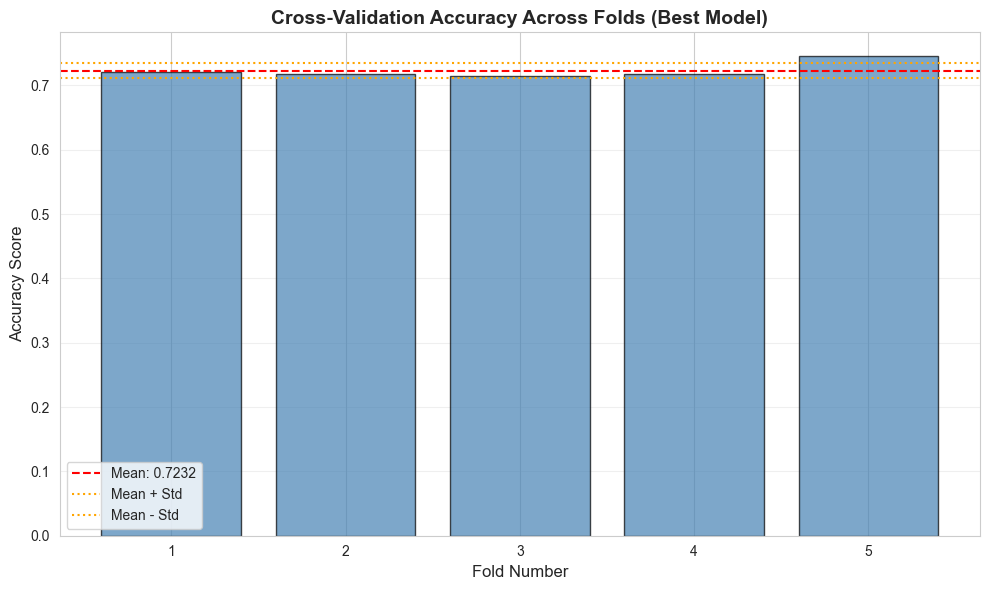

In [14]:
# Visualize CV fold scores
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), fold_scores, alpha=0.7, color='steelblue', edgecolor='black')
plt.axhline(y=np.mean(fold_scores), color='red', linestyle='--', label=f'Mean: {np.mean(fold_scores):.4f}')
plt.axhline(y=np.mean(fold_scores) + np.std(fold_scores), color='orange', linestyle=':', label=f'Mean + Std')
plt.axhline(y=np.mean(fold_scores) - np.std(fold_scores), color='orange', linestyle=':', label=f'Mean - Std')
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title('Cross-Validation Accuracy Across Folds (Best Model)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Model Evaluation on Test Set

In [15]:
# Get the best model
best_model = grid_search.best_estimator_

# Make predictions on test set
y_pred = best_model.predict(X_test_scaled)
y_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print("="*60)

TEST SET RESULTS
Test Accuracy: 0.7146


In [16]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Good (0)', 'Bad (1)']))


Classification Report:
              precision    recall  f1-score   support

    Good (0)       0.72      0.67      0.69      1000
     Bad (1)       0.71      0.76      0.74      1092

    accuracy                           0.71      2092
   macro avg       0.71      0.71      0.71      2092
weighted avg       0.71      0.71      0.71      2092



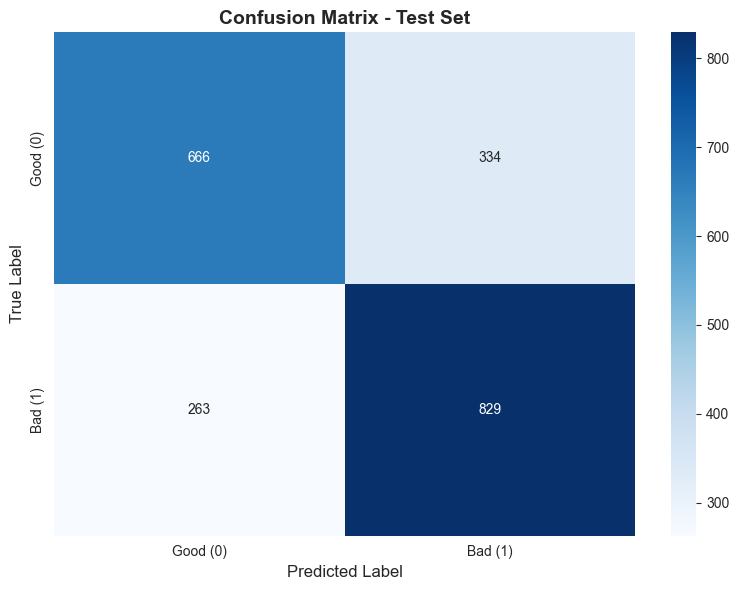


True Negatives: 666
False Positives: 334
False Negatives: 263
True Positives: 829


In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Good (0)', 'Bad (1)'],
            yticklabels=['Good (0)', 'Bad (1)'])
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

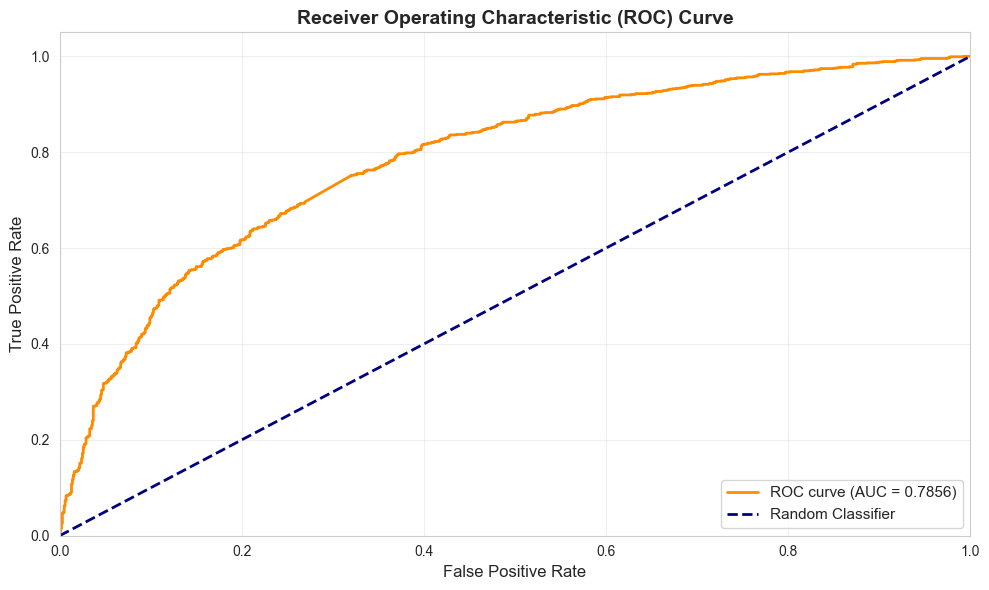


AUC-ROC Score: 0.7856


In [18]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAUC-ROC Score: {roc_auc:.4f}")

## 9. Feature Importance Analysis

In [19]:
# Get feature coefficients
coefficients = best_model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': variable_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values('Abs_Coefficient', ascending=False)

print("\nTop 15 Most Important Features (by absolute coefficient):")
print(feature_importance.head(15).to_string(index=False))


Top 15 Most Important Features (by absolute coefficient):
                           Feature  Coefficient  Abs_Coefficient
              ExternalRiskEstimate    -0.288079         0.288079
        NetFractionRevolvingBurden     0.209807         0.209807
                    AverageMInFile    -0.163816         0.163816
NumBank2NatlTradesWHighUtilization     0.144126         0.144126
      MSinceMostRecentInqexcl7days    -0.138117         0.138117
            PercentTradesNeverDelq    -0.132658         0.132658
             NumSatisfactoryTrades    -0.130646         0.130646
          MaxDelq2PublicRecLast12M    -0.110604         0.110604
             MSinceOldestTradeOpen    -0.102749         0.102749
             PercentTradesWBalance     0.091424         0.091424
              PercentInstallTrades     0.086390         0.086390
                       MaxDelqEver    -0.085032         0.085032
                      NumInqLast6M     0.079949         0.079949
                    NumTotalTra

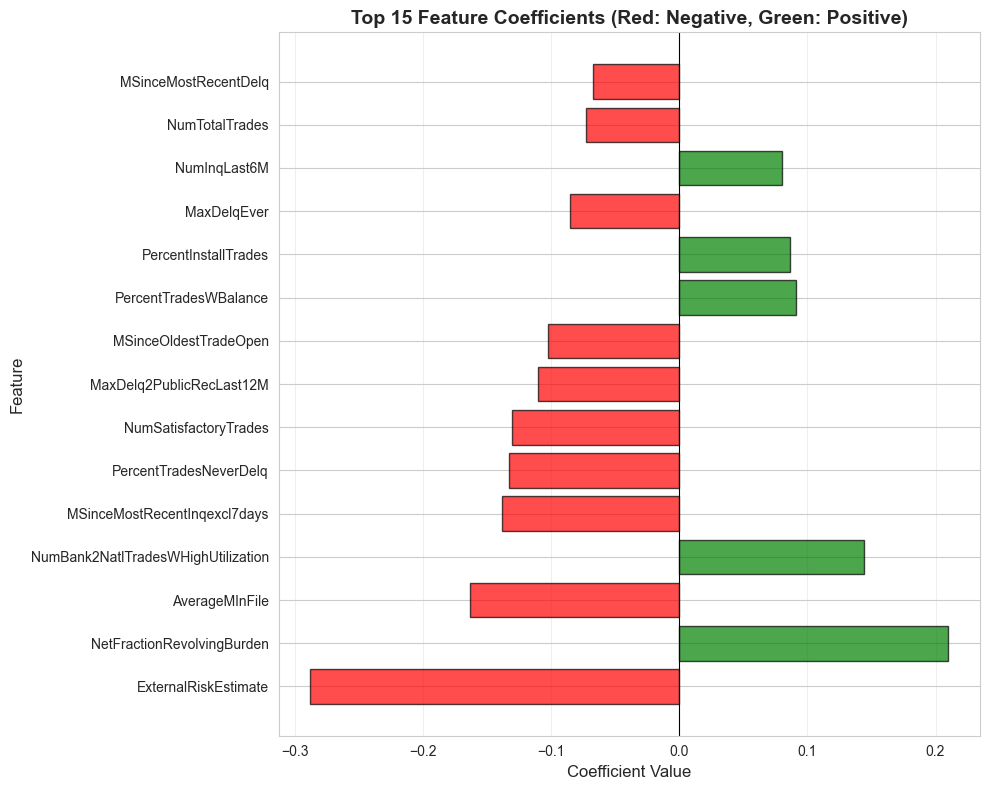

In [20]:
# Visualize top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in top_features['Coefficient']]
plt.barh(range(len(top_features)), top_features['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Feature Coefficients (Red: Negative, Green: Positive)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Summary

In [21]:
print("="*70)
print("LOGISTIC REGRESSION MODEL SUMMARY")
print("="*70)
print("\n📊 DATASET INFORMATION:")
print(f"  Total samples: {len(df)}")
print(f"  Number of features: {len(variable_names)}")
print(f"  Training samples: {len(X_train)}")
print(f"  Test samples: {len(X_test)}")

print("\n🔧 BEST HYPERPARAMETERS:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print("\n📈 CROSS-VALIDATION PERFORMANCE:")
print(f"  Mean CV Accuracy: {grid_search.best_score_:.4f}")
print(f"  CV Std Dev: {np.std(fold_scores):.4f}")
print(f"  CV Variance: {np.var(fold_scores):.6f}")

print("\n🎯 TEST SET PERFORMANCE:")
print(f"  Test Accuracy: {test_accuracy:.4f}")
print(f"  AUC-ROC Score: {roc_auc:.4f}")

print("\n✅ MODEL STABILITY:")
cv_std = np.std(fold_scores)
if cv_std < 0.01:
    print("  Status: Excellent (Very low variance)")
elif cv_std < 0.02:
    print("  Status: Good (Low variance)")
elif cv_std < 0.03:
    print("  Status: Moderate (Acceptable variance)")
else:
    print("  Status: Warning (High variance)")

print("\n" + "="*70)

LOGISTIC REGRESSION MODEL SUMMARY

📊 DATASET INFORMATION:
  Total samples: 10459
  Number of features: 23
  Training samples: 8367
  Test samples: 2092

🔧 BEST HYPERPARAMETERS:
  C: 0.001
  class_weight: None
  max_iter: 1000
  penalty: l2
  solver: saga

📈 CROSS-VALIDATION PERFORMANCE:
  Mean CV Accuracy: 0.7232
  CV Std Dev: 0.0113
  CV Variance: 0.000127

🎯 TEST SET PERFORMANCE:
  Test Accuracy: 0.7146
  AUC-ROC Score: 0.7856

✅ MODEL STABILITY:
  Status: Good (Low variance)

